In [ ]:
!pip install pycocotools matplotlib opencv-python numpy

In [ ]:
import os
import json
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pycocotools.coco import COCO
import random
from glob import glob

In [ ]:
# Set your paths
train_folder = "/content/drive/MyDrive/Colab Notebooks/BrainT/1/train"  # Update this path
annotation_file = os.path.join(train_folder, "_annotations.coco.json")  # COCO format annotation file

# Load COCO annotations
coco = COCO(annotation_file)

# Get category information
categories = coco.loadCats(coco.getCatIds())
category_names = [cat['name'] for cat in categories]
print(f"Categories found: {category_names}")


loading annotations into memory...
Done (t=0.47s)
creating index...
index created!
Categories found: ['Tumor', '0', '1']


In [ ]:
# Helper Functions for Visualization
def display_image(image, title="Image", cmap=None):
    """Display a single image"""
    plt.figure(figsize=(8, 8))
    if len(image.shape) == 2:
        plt.imshow(image, cmap='gray')
    else:
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

def display_multiple_images(images, titles, rows=1, cols=3, figsize=(15, 5)):
    """Display multiple images in a grid"""
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten() if rows * cols > 1 else [axes]

    for idx, (image, title) in enumerate(zip(images, titles)):
        if len(image.shape) == 2:
            axes[idx].imshow(image, cmap='gray')
        else:
            axes[idx].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        axes[idx].set_title(title)
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

def load_and_preprocess_image(image_path, target_size=None):
    """Load and preprocess an image"""
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    if target_size:
        image = cv2.resize(image, target_size)

    return image

In [ ]:
# Load Sample Images and Annotations
# Get all image IDs
img_ids = coco.getImgIds()
print(f"Total images in dataset: {len(img_ids)}")

# Get a random sample image
random_img_id = random.choice(img_ids)
img_info = coco.loadImgs(random_img_id)[0]

# Load the image
image_path = os.path.join(train_folder, img_info['file_name'])
original_image = load_and_preprocess_image(image_path)

print(f"Selected Image: {img_info['file_name']}")
print(f"Image size: {original_image.shape}")

# Get annotations for this image
ann_ids = coco.getAnnIds(imgIds=random_img_id)
annotations = coco.loadAnns(ann_ids)
print(f"Number of annotations: {len(annotations)}")

Total images in dataset: 1502
Selected Image: 274_jpg.rf.67ec4092b03ab1c95a888d65006d0f9b.jpg
Image size: (640, 640, 3)
Number of annotations: 1


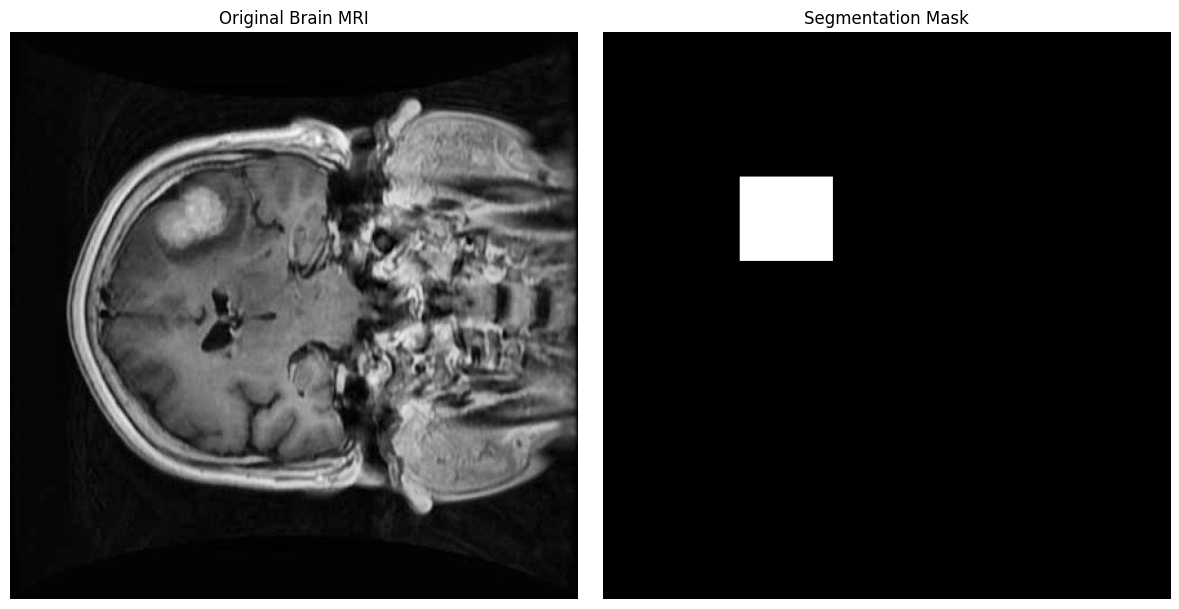

In [ ]:
# Create Segmentation Mask from COCO Annotations
def create_segmentation_mask(coco, img_info, annotations):
    """Create a binary mask from COCO annotations"""
    # Create empty mask
    height, width = img_info['height'], img_info['width']
    mask = np.zeros((height, width), dtype=np.uint8)

    # For each annotation (each tumor region)
    for ann in annotations:
        # Get segmentation polygon
        segmentation = ann['segmentation']

        # COCO segmentation can be a list of polygons
        if isinstance(segmentation, list):
            for poly in segmentation:
                # Reshape to (n_points, 2)
                poly = np.array(poly).reshape(-1, 2).round().astype(np.int32)
                cv2.fillPoly(mask, [poly], 255)

    return mask

# Create mask
segmentation_mask = create_segmentation_mask(coco, img_info, annotations)

# Display original and mask
display_multiple_images(
    [original_image, segmentation_mask],
    ["Original Brain MRI", "Segmentation Mask"],
    rows=1, cols=2, figsize=(12, 6)
)

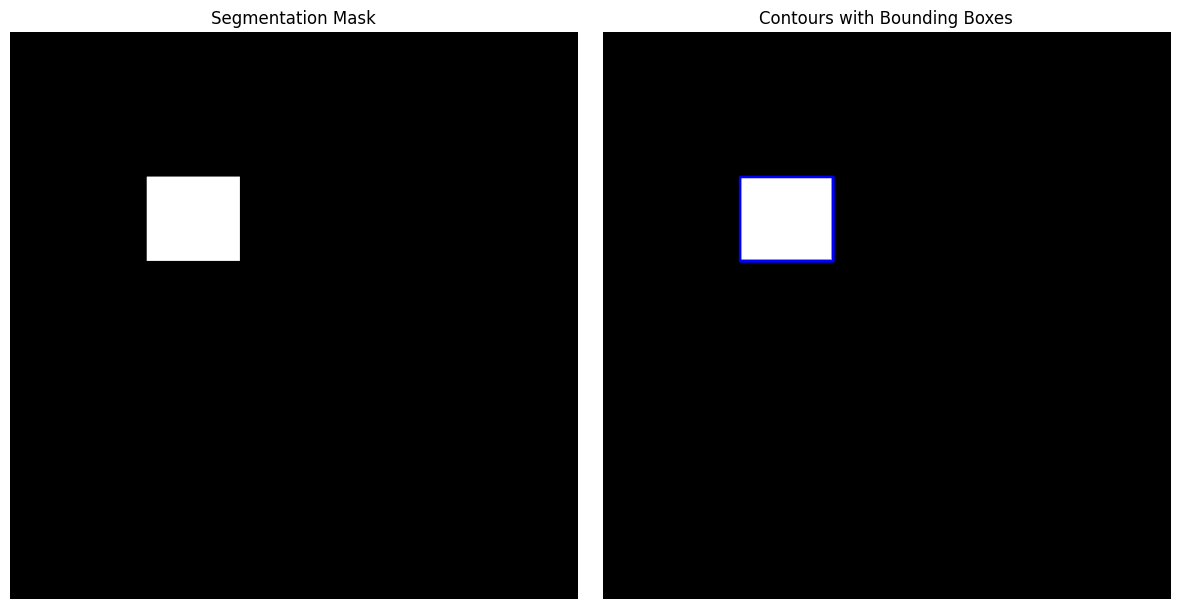

In [ ]:
# Contouring on Segmentation Mask
def extract_and_draw_contours(mask, min_area=50):
    """Extract contours and draw them on a copy of the mask"""
    # Find contours
    contours, hierarchy = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    # Filter small contours
    filtered_contours = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area > min_area:
            filtered_contours.append(cnt)

    # Create contour visualization
    contour_vis = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
    cv2.drawContours(contour_vis, filtered_contours, -1, (0, 255, 0), 2)

    # Draw bounding boxes
    for cnt in filtered_contours:
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(contour_vis, (x, y), (x + w, y + h), (255, 0, 0), 2)

    return filtered_contours, contour_vis

# Extract contours
contours, contour_image = extract_and_draw_contours(segmentation_mask)

# Display
display_multiple_images(
    [segmentation_mask, contour_image],
    ["Segmentation Mask", "Contours with Bounding Boxes"],
    rows=1, cols=2, figsize=(12, 6)
)


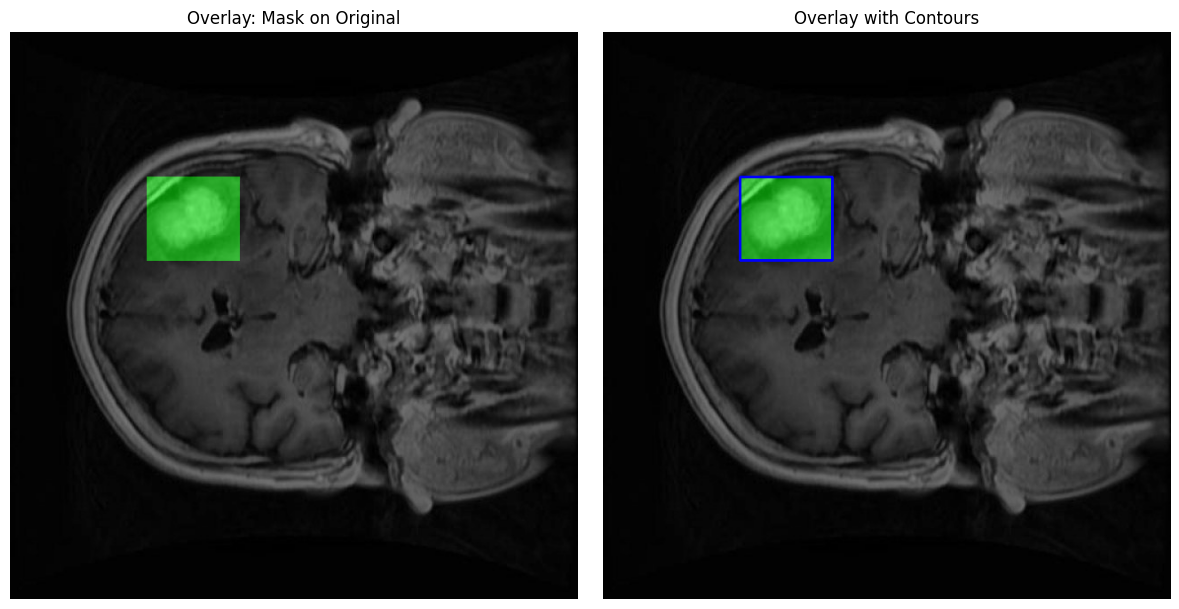

In [ ]:
# Overlay Visualization
def create_overlay(image, mask, alpha=0.5):
    """Create an overlay of mask on original image"""
    # Create colored mask (green for tumor)
    colored_mask = np.zeros_like(image)
    colored_mask[mask > 0] = [0, 255, 0]  # Green color

    # Create overlay
    overlay = cv2.addWeighted(image, 1 - alpha, colored_mask, alpha, 0)

    # Add contours to overlay
    overlay_with_contours = overlay.copy()
    cv2.drawContours(overlay_with_contours, contours, -1, (255, 0, 0), 2)  # Blue contours

    return overlay, overlay_with_contours

# Create overlays
overlay, overlay_with_contours = create_overlay(original_image, segmentation_mask)

# Display
display_multiple_images(
    [overlay, overlay_with_contours],
    ["Overlay: Mask on Original", "Overlay with Contours"],
    rows=1, cols=2, figsize=(12, 6)
)


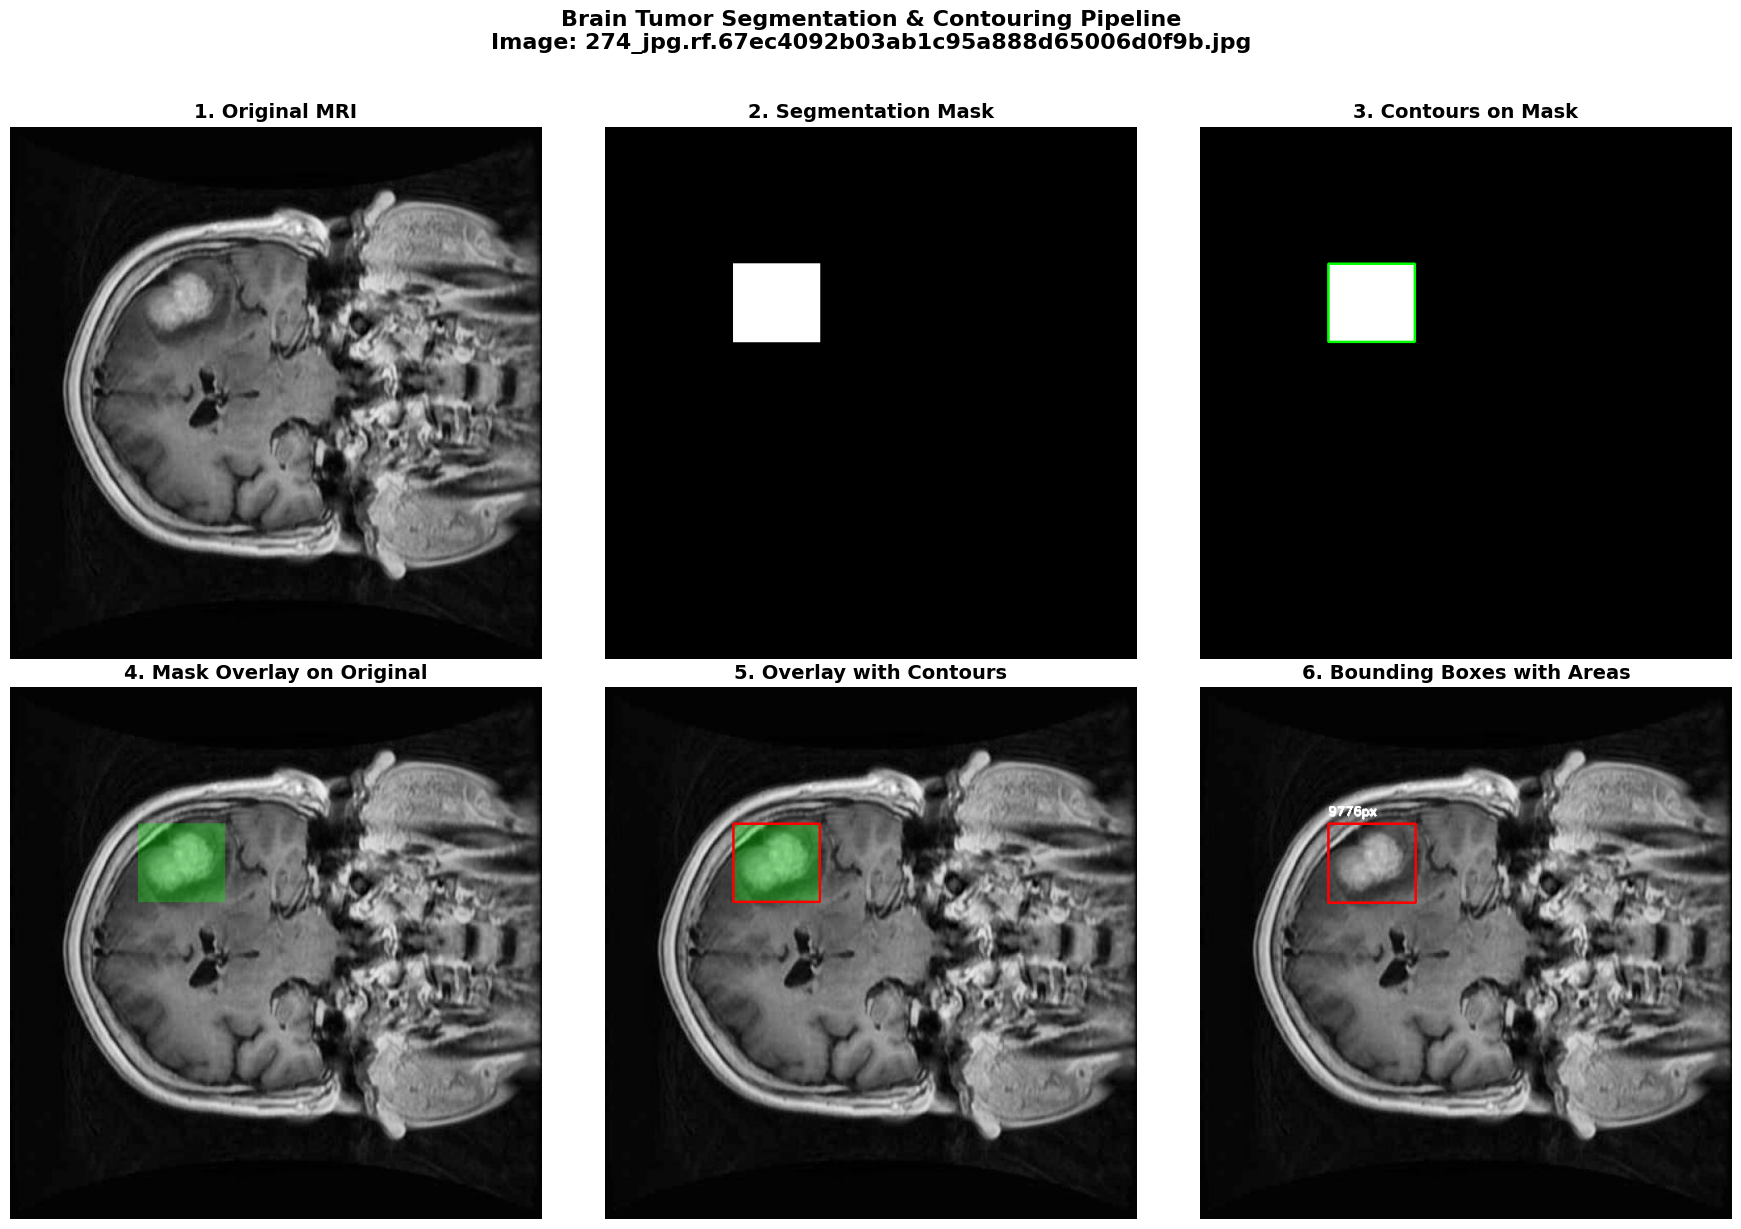

In [ ]:
# Complete Visualization Pipeline
def visualize_complete_pipeline(original, mask, contours):
    """Show complete segmentation and contouring pipeline"""
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    # Original image
    axes[0, 0].imshow(original)
    axes[0, 0].set_title('1. Original MRI', fontsize=14, fontweight='bold')
    axes[0, 0].axis('off')

    # Segmentation mask
    axes[0, 1].imshow(mask, cmap='gray')
    axes[0, 1].set_title('2. Segmentation Mask', fontsize=14, fontweight='bold')
    axes[0, 1].axis('off')

    # Contours on mask
    contour_mask = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
    cv2.drawContours(contour_mask, contours, -1, (0, 255, 0), 2)
    axes[0, 2].imshow(contour_mask)
    axes[0, 2].set_title('3. Contours on Mask', fontsize=14, fontweight='bold')
    axes[0, 2].axis('off')

    # Overlay
    overlay = original.copy()
    overlay[mask > 0] = [0, 255, 0]  # Green overlay
    overlay = cv2.addWeighted(original, 0.7, overlay, 0.3, 0)
    axes[1, 0].imshow(overlay)
    axes[1, 0].set_title('4. Mask Overlay on Original', fontsize=14, fontweight='bold')
    axes[1, 0].axis('off')

    # Overlay with contours
    overlay_with_contours = overlay.copy()
    cv2.drawContours(overlay_with_contours, contours, -1, (255, 0, 0), 2)
    axes[1, 1].imshow(overlay_with_contours)
    axes[1, 1].set_title('5. Overlay with Contours', fontsize=14, fontweight='bold')
    axes[1, 1].axis('off')

    # Bounding boxes
    bbox_image = original.copy()
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(bbox_image, (x, y), (x + w, y + h), (255, 0, 0), 2)
        # Add area text
        area = cv2.contourArea(cnt)
        cv2.putText(bbox_image, f"{area:.0f}px", (x, y-10),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)
    axes[1, 2].imshow(bbox_image)
    axes[1, 2].set_title('6. Bounding Boxes with Areas', fontsize=14, fontweight='bold')
    axes[1, 2].axis('off')

    plt.suptitle(f"Brain Tumor Segmentation & Contouring Pipeline\nImage: {img_info['file_name']}",
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# Run complete visualization
visualize_complete_pipeline(original_image, segmentation_mask, contours)


In [ ]:
# Tumor Analysis and Statistics
print("\n" + "="*50)
print("TUMOR ANALYSIS REPORT")
print("="*50)

if len(contours) > 0:
    for i, cnt in enumerate(contours):
        area = cv2.contourArea(cnt)
        perimeter = cv2.arcLength(cnt, True)
        x, y, w, h = cv2.boundingRect(cnt)

        print(f"\nTumor Region {i+1}:")
        print(f"  - Area: {area:.2f} pixels")
        print(f"  - Perimeter: {perimeter:.2f} pixels")
        print(f"  - Bounding Box: ({x}, {y}) to ({x+w}, {y+h})")
        print(f"  - Dimensions: {w} x {h} pixels")

        # Calculate some shape features
        if perimeter > 0:
            circularity = 4 * np.pi * area / (perimeter * perimeter)
            print(f"  - Circularity: {circularity:.3f} (1 = perfect circle)")

        # Aspect ratio
        aspect_ratio = float(w) / h if h > 0 else 0
        print(f"  - Aspect Ratio: {aspect_ratio:.2f}")

    total_area = sum(cv2.contourArea(cnt) for cnt in contours)
    image_area = original_image.shape[0] * original_image.shape[1]
    tumor_percentage = (total_area / image_area) * 100

    print(f"\nSUMMARY:")
    print(f"  - Total Tumor Regions: {len(contours)}")
    print(f"  - Total Tumor Area: {total_area:.2f} pixels")
    print(f"  - Image Area: {image_area} pixels")
    print(f"  - Tumor Coverage: {tumor_percentage:.2f}% of image")
else:
    print("No tumor regions detected in this image.")


TUMOR ANALYSIS REPORT

Tumor Region 1:
  - Area: 9776.00 pixels
  - Perimeter: 396.00 pixels
  - Bounding Box: (154, 164) to (259, 259)
  - Dimensions: 105 x 95 pixels
  - Circularity: 0.783 (1 = perfect circle)
  - Aspect Ratio: 1.11

SUMMARY:
  - Total Tumor Regions: 1
  - Total Tumor Area: 9776.00 pixels
  - Image Area: 409600 pixels
  - Tumor Coverage: 2.39% of image



PROCESSING SAMPLE 1/5


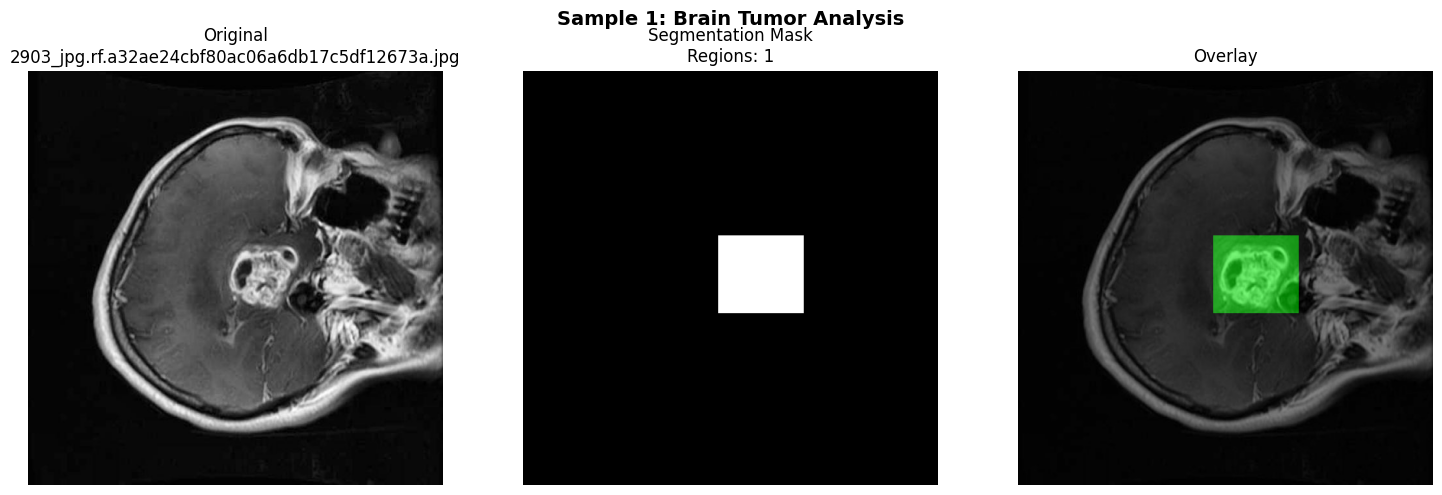

  Detected 1 tumor region(s)
  Total tumor area: 15589 pixels

PROCESSING SAMPLE 2/5


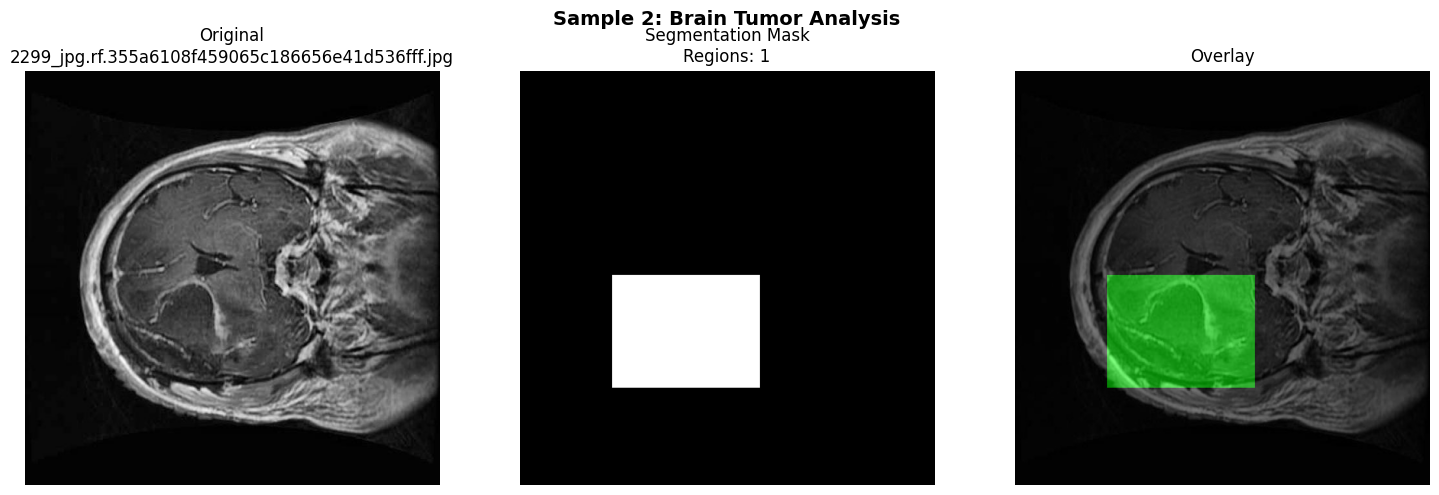

  Detected 1 tumor region(s)
  Total tumor area: 39271 pixels

PROCESSING SAMPLE 3/5


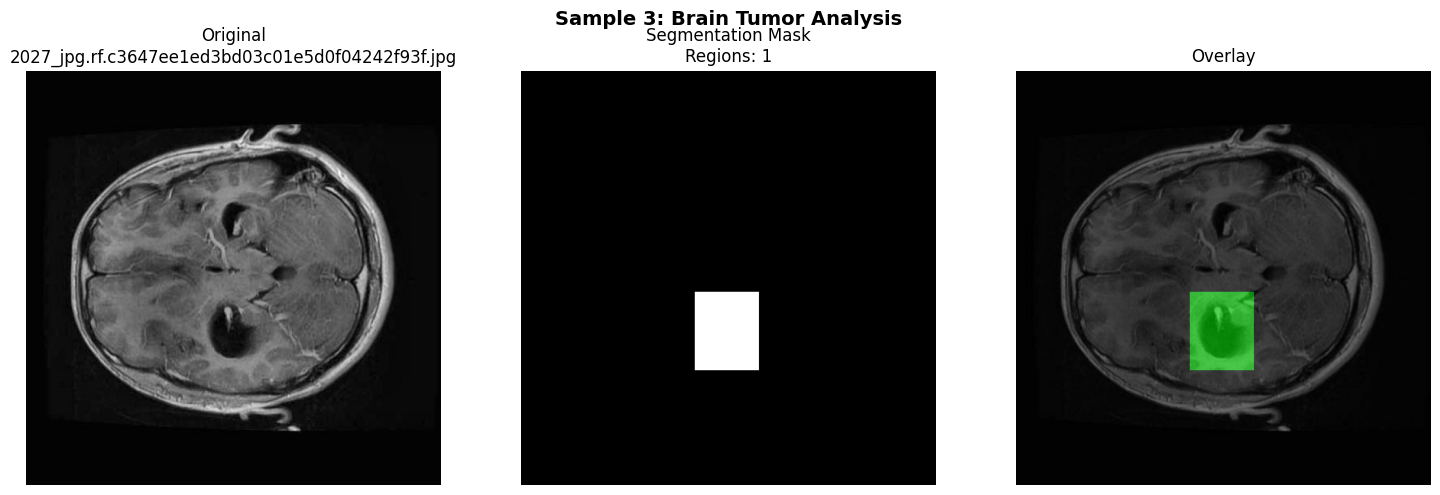

  Detected 1 tumor region(s)
  Total tumor area: 11760 pixels

PROCESSING SAMPLE 4/5


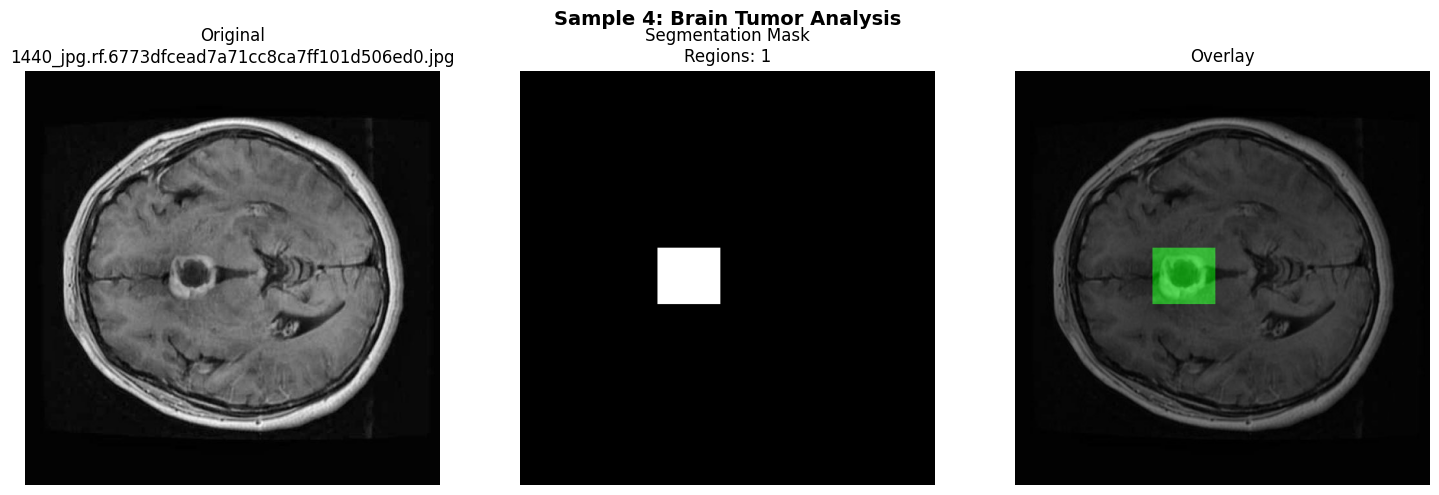

  Detected 1 tumor region(s)
  Total tumor area: 8256 pixels

PROCESSING SAMPLE 5/5


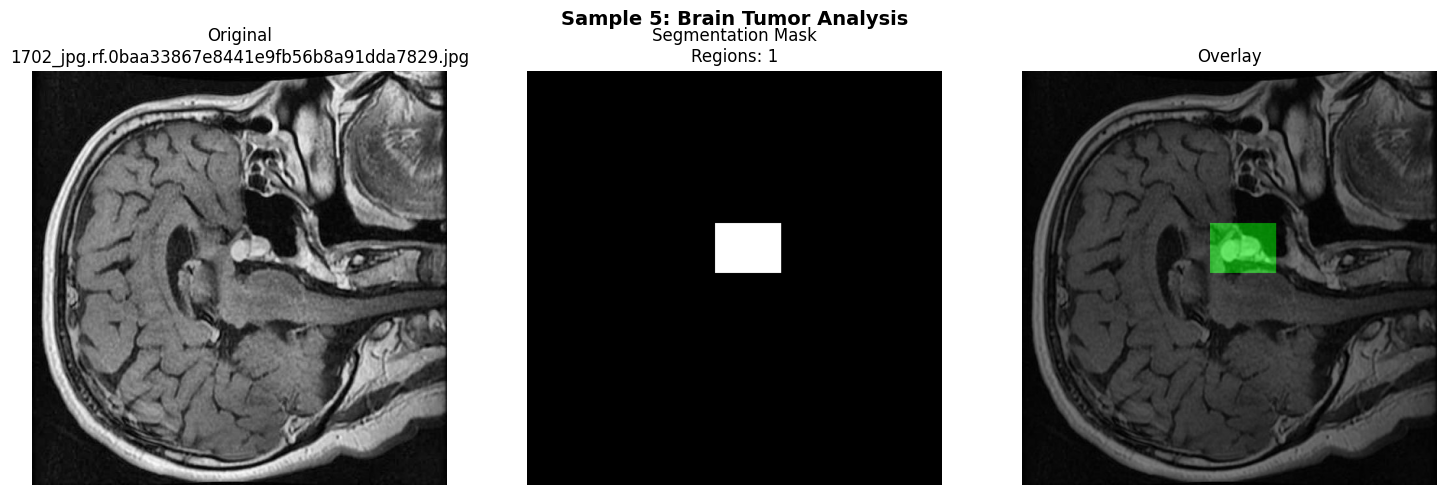

  Detected 1 tumor region(s)
  Total tumor area: 7676 pixels


In [ ]:
# Process Multiple Images
def process_multiple_images(coco, train_folder, num_samples=3):
    """Process and display multiple random images"""
    img_ids = coco.getImgIds()
    sample_ids = random.sample(img_ids, min(num_samples, len(img_ids)))

    for i, img_id in enumerate(sample_ids):
        print(f"\n{'='*60}")
        print(f"PROCESSING SAMPLE {i+1}/{len(sample_ids)}")
        print(f"{'='*60}")

        # Load image info
        img_info = coco.loadImgs(img_id)[0]
        image_path = os.path.join(train_folder, img_info['file_name'])

        # Load image
        image = load_and_preprocess_image(image_path)

        # Get annotations and create mask
        ann_ids = coco.getAnnIds(imgIds=img_id)
        annotations = coco.loadAnns(ann_ids)
        mask = create_segmentation_mask(coco, img_info, annotations)

        # Extract contours
        contours, _ = extract_and_draw_contours(mask)

        # Create overlay
        overlay, _ = create_overlay(image, mask)

        # Display
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        axes[0].imshow(image)
        axes[0].set_title(f'Original\n{img_info["file_name"]}')
        axes[0].axis('off')

        axes[1].imshow(mask, cmap='gray')
        axes[1].set_title(f'Segmentation Mask\nRegions: {len(contours)}')
        axes[1].axis('off')

        axes[2].imshow(overlay)
        axes[2].set_title('Overlay')
        axes[2].axis('off')

        plt.suptitle(f'Sample {i+1}: Brain Tumor Analysis', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

        # Print quick stats
        total_area = sum(cv2.contourArea(cnt) for cnt in contours) if contours else 0
        print(f"  Detected {len(contours)} tumor region(s)")
        print(f"  Total tumor area: {total_area:.0f} pixels")

# Process 3 random images
process_multiple_images(coco, train_folder, num_samples=5)


SIMPLE THRESHOLD-BASED SEGMENTATION (No Annotations Needed)


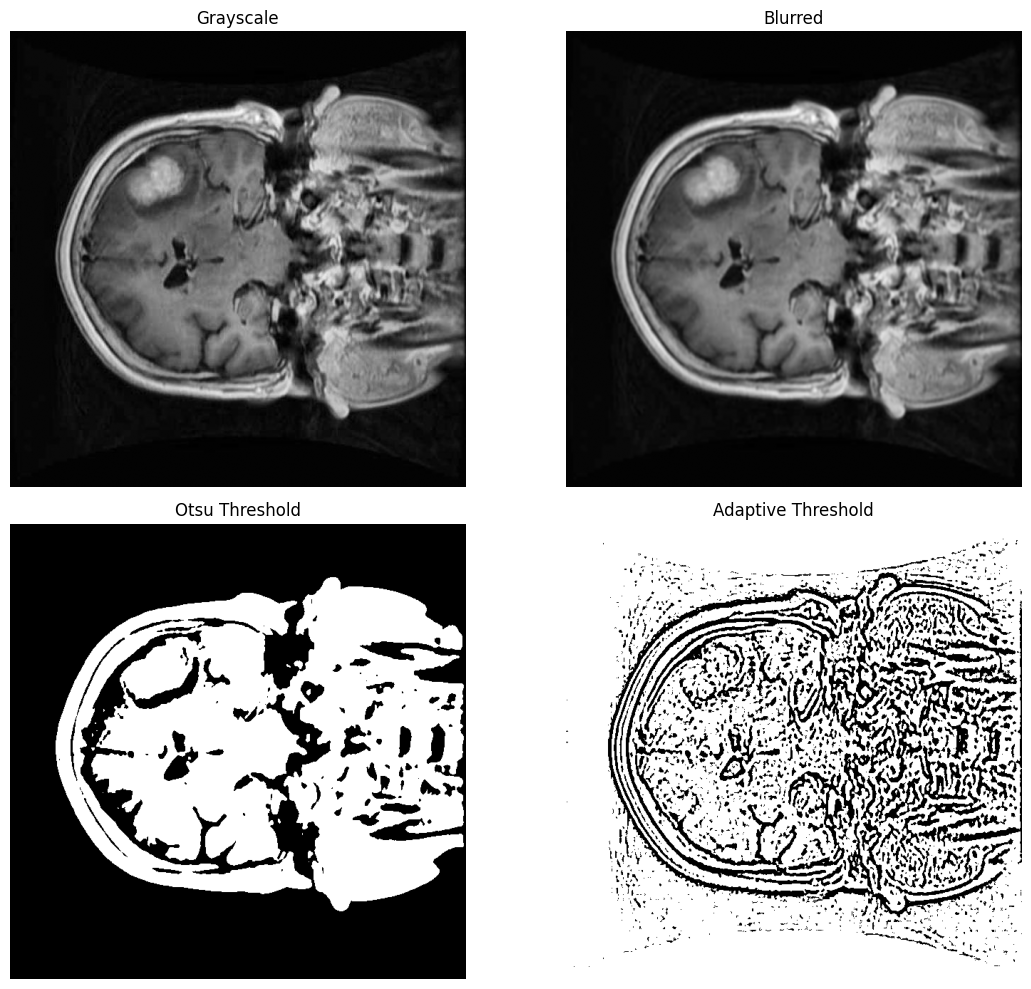

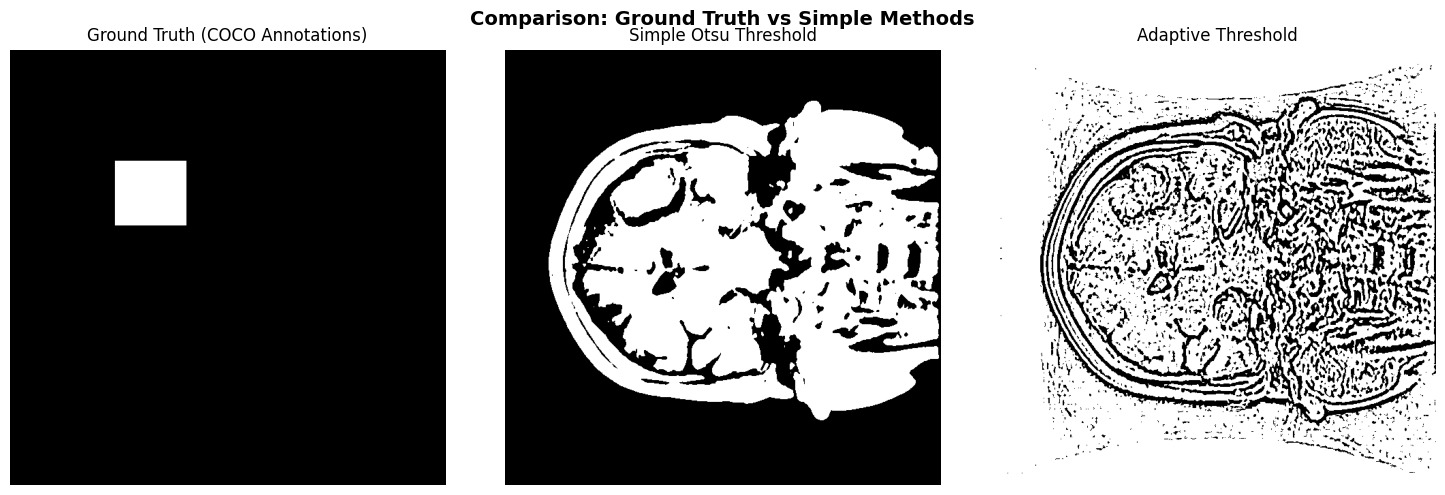

In [ ]:
# Simple Threshold-based Segmentation
def simple_threshold_segmentation(image, display=True):
    """Simple segmentation using thresholding (no annotations needed)"""
    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    # Apply Gaussian blur
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # Try different thresholding methods
    # Method 1: Simple threshold
    _, thresh1 = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Method 2: Adaptive threshold
    thresh2 = cv2.adaptiveThreshold(blurred, 255,
                                    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                    cv2.THRESH_BINARY, 11, 2)

    if display:
        display_multiple_images(
            [gray, blurred, thresh1, thresh2],
            ["Grayscale", "Blurred", "Otsu Threshold", "Adaptive Threshold"],
            rows=2, cols=2, figsize=(12, 10)
        )

    return thresh1, thresh2

# Try simple segmentation on a sample image
print("\n" + "="*60)
print("SIMPLE THRESHOLD-BASED SEGMENTATION (No Annotations Needed)")
print("="*60)

simple_mask1, simple_mask2 = simple_threshold_segmentation(original_image)

# Compare with ground truth
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(segmentation_mask, cmap='gray')
axes[0].set_title('Ground Truth (COCO Annotations)')
axes[0].axis('off')

axes[1].imshow(simple_mask1, cmap='gray')
axes[1].set_title('Simple Otsu Threshold')
axes[1].axis('off')

axes[2].imshow(simple_mask2, cmap='gray')
axes[2].set_title('Adaptive Threshold')
axes[2].axis('off')

plt.suptitle('Comparison: Ground Truth vs Simple Methods', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# Save Results
def save_results(image, mask, contours, base_filename="results"):
    """Save all results to files"""
    os.makedirs("results", exist_ok=True)

    # Save original
    cv2.imwrite(f"results/{base_filename}_original.png",
                cv2.cvtColor(image, cv2.COLOR_RGB2BGR))

    # Save mask
    cv2.imwrite(f"results/{base_filename}_mask.png", mask)

    # Save mask with contours
    mask_with_contours = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
    cv2.drawContours(mask_with_contours, contours, -1, (0, 255, 0), 2)
    cv2.imwrite(f"results/{base_filename}_mask_contours.png", mask_with_contours)

    # Save overlay
    overlay = image.copy()
    overlay[mask > 0] = [0, 255, 0]
    overlay = cv2.addWeighted(image, 0.7, overlay, 0.3, 0)
    cv2.imwrite(f"results/{base_filename}_overlay.png",
                cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

    print(f"Results saved to 'results/' folder")

# Save results
save_results(original_image, segmentation_mask, contours,
             base_filename=img_info['file_name'].split('.')[0])

Results saved to 'results/' folder
